Loaded: RN50_20250623_214602  |  images 2000


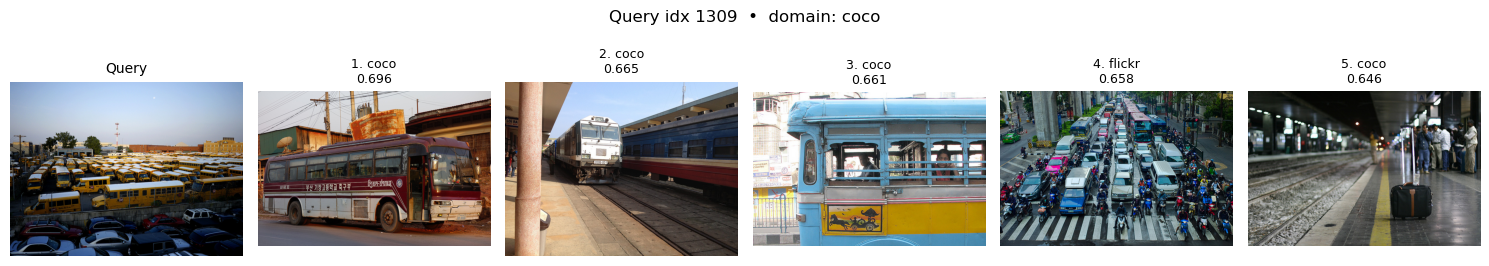

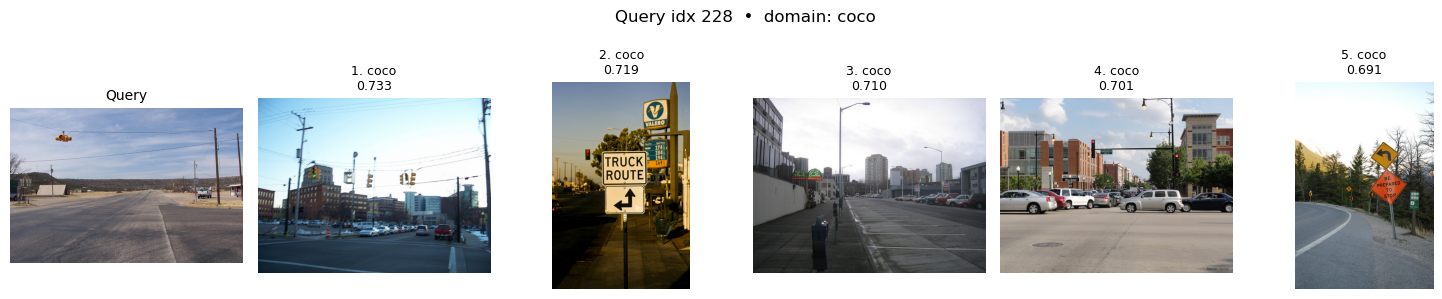

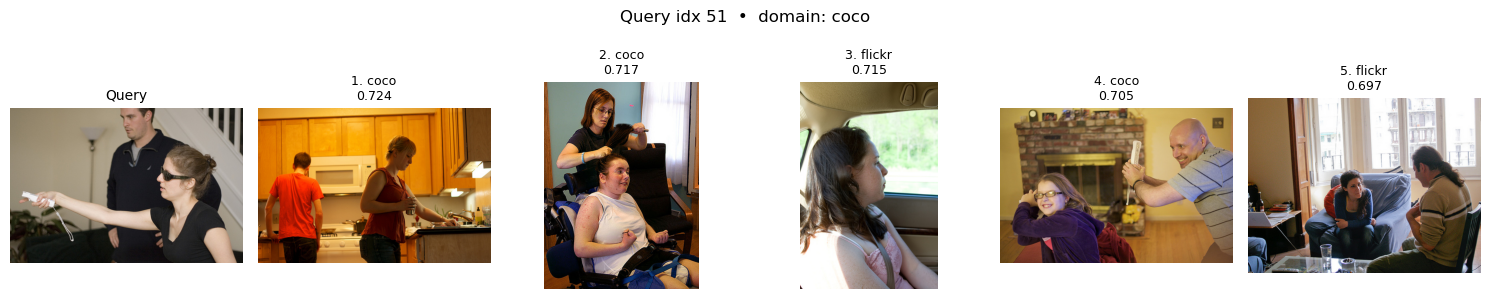

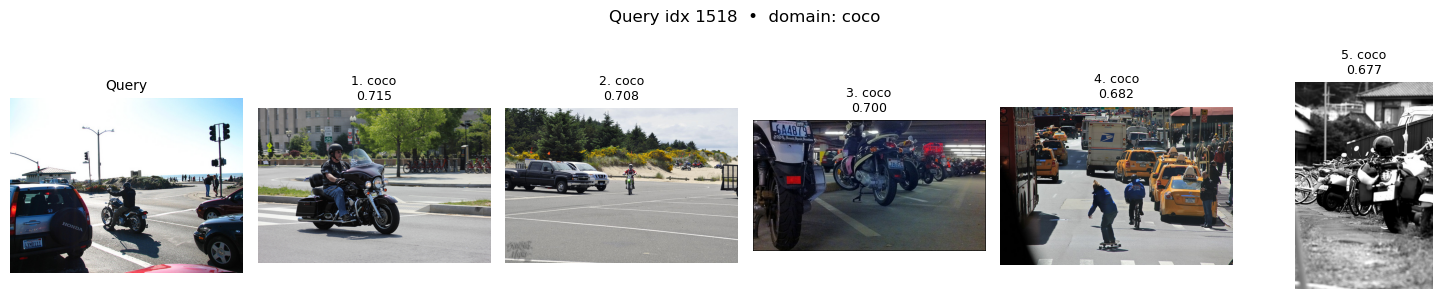

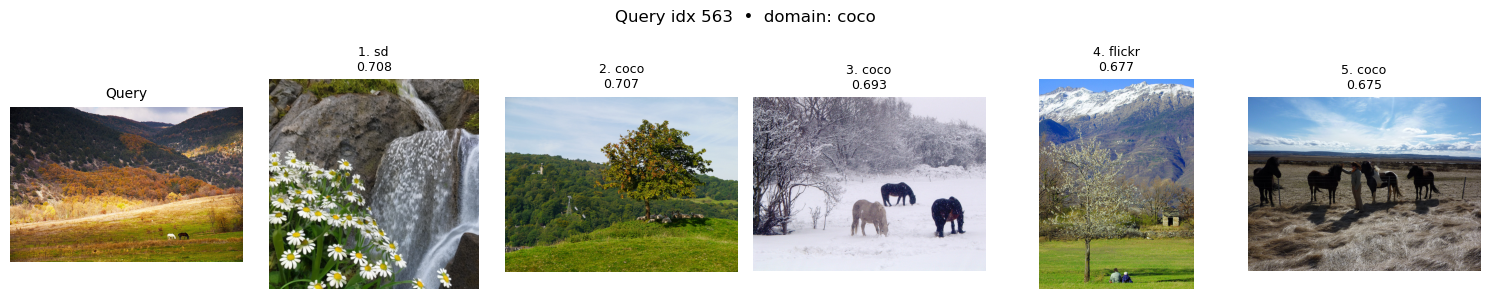

In [ ]:
# Qualitative demo: given a query image, show its top‑K nearest
# neighbour images (cosine similarity) across the whole run.


from pathlib import Path
import json, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from numpy.linalg import norm

RUN_DIR = Path("experiments/RN50_20250623_214602")   # <- change as needed
PARQUET = Path(r"C:/Users/steph/OneDrive/Desktop/data/metadata.parquet")
IMG_EMB = np.load(RUN_DIR / "img_embs.npy").astype("float32")
IDS     = json.loads((RUN_DIR / "ids.json").read_text())
META    = pd.read_parquet(PARQUET).set_index("id").loc[IDS]

# L2‑norm once for cosine
img_norm = IMG_EMB / norm(IMG_EMB, axis=1, keepdims=True)

print(f"Loaded: {RUN_DIR.name}  |  images {IMG_EMB.shape[0]}")

DATA_ROOT = Path(r"C:/Users/steph/OneDrive/Desktop/data")

def open_image(row):
    if "image_path" in row:
        return Image.open(Path(row["image_path"])).convert("RGB")
    domain = row["domain"]
    img_id = row.get("image_id", None)
    if img_id is None:
        raise KeyError("Row lacks 'image_id'. Add 'image_path' to metadata or keep image_id column.")

    if domain == "coco":
        img_path = DATA_ROOT / "coco" / "train2017" / f"{int(img_id):012d}.jpg"
    elif domain == "sd":
        img_path = DATA_ROOT / "SD" / "images" / img_id
    else:  # flickr
        img_path = DATA_ROOT / "flickr30k" / "flickr30k_images" / img_id

    return Image.open(img_path).convert("RGB").convert("RGB")

N_QUERIES = 5
random.seed(42)
query_indices = random.sample(range(img_norm.shape[0]), k=N_QUERIES)

K = 5  # neighbours to display

# Visualise neighbours for each query
for qi in query_indices:
    q_vec = img_norm[qi]
    sim   = q_vec @ img_norm.T
    sim[qi] = -1.0
    nn_idx = np.argpartition(-sim, K)[:K]
    nn_idx = nn_idx[np.argsort(-sim[nn_idx])]  # sort by similarity

    fig, axes = plt.subplots(1, K + 1, figsize=(2.5*(K+1), 3))
    fig.suptitle(f"Query idx {qi}  •  domain: {META.iloc[qi].domain}")

    axes[0].imshow(open_image(META.iloc[qi]))
    axes[0].set_title("Query", fontsize=10)
    axes[0].axis("off")

    # show neighbours
    for rank, idx in enumerate(nn_idx, 1):
        row = META.iloc[idx]
        axes[rank].imshow(open_image(row))
        axes[rank].set_title(f"{rank}. {row.domain}\n{sim[idx]:.3f}", fontsize=9)
        axes[rank].axis("off")

    plt.tight_layout()
    plt.show()
